In [15]:
from scrape_guardian import scrape_guardian_headlines

In [11]:
from datetime import datetime

In [12]:
my_date=datetime(2024, 1, 1)

In [13]:
headlines = scrape_guardian_headlines(my_date)

In [14]:
headlines

['Japan earthquakes: ‘battle against time’ to find those trapped under rubble as death toll rises',
 'Ethiopia and Somaliland reach agreement over access to ports',
 'Japan orders people to evacuate after 7.6-magnitude quake hits west coast',
 'Israel supreme court strikes down Netanyahu’s judicial overhaul law',
 'Displaced woman gives birth to quadruplets in central Gaza – video',
 'Japan earthquake news – as it happened: highest-level tsunami warning dropped',
 '‘All of Denmark is crying’: Danes react to Margrethe II’s abdication',
 'Russia launches 90 drone attacks on Ukraine in early hours of new year',
 'Israel to withdraw some troops from Gaza amid new campaign planning',
 'Iran rejects US and UK calls to end support for Houthi Red Sea attacks',
 'Why Labour needs to decide whether to break the consensus on Israel',
 'Russia-Ukraine war: Putin calls Ukrainian strikes on Belgorod ‘terrorist act’ that ‘will not go unpunished’ – as it happened',
 'Italy’s oldest man, Tripoli Gianni

## Part II: Analysis

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../dataset/guardian_headlines.csv")
df.head()

,date,headline
0,2019-01-01,Jair Bolsonaro takes office as Brazil’s presid...
1,2019-01-01,Indonesia landslide on New Year's Eve leaves 1...
2,2019-01-01,Terrawatch: landslide tsunami lessons from Ana...
3,2019-01-01,Mali attack: 37 civilians killed in armed raid...
4,2019-01-01,Bolsonaro declares Brazil's 'liberation from s...


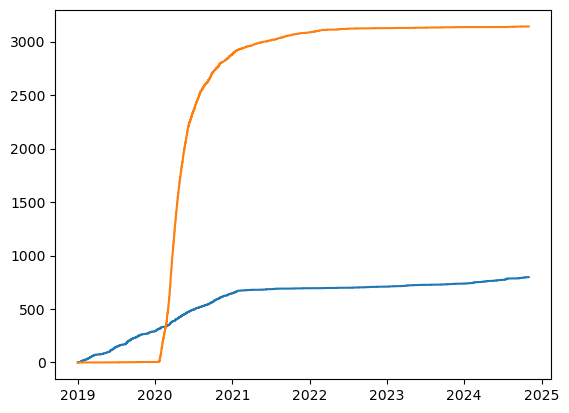

In [18]:
# make a timeseries plot counting the number of times the word "Trump" appears in the headlines across time
df['date'] = pd.to_datetime(df['date'])
df['trump'] = df['headline'].str.contains('Trump', case=False)
df['covid'] = df['headline'].str.contains('virus', case=False)

plt.plot(df['date'], df['trump'].cumsum())
plt.plot(df['date'], df['covid'].cumsum())

<Axes: xlabel='month'>

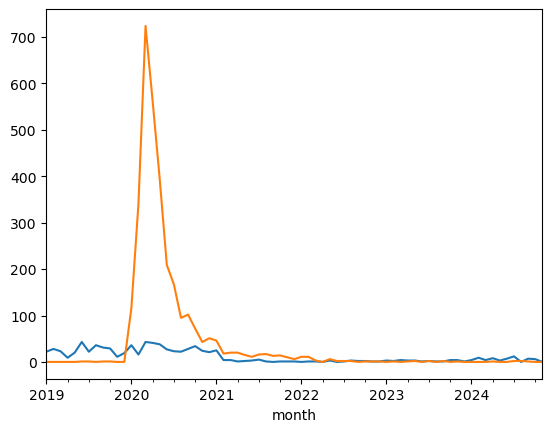

In [20]:
df.head()
# group the df by month and count the number of times the word "Trump" appears in the headlines
df['month'] = df['date'].dt.to_period('M')
df.groupby('month')['trump'].sum().plot()
df.groupby('month')['covid'].sum().plot()

In [21]:
def compare_two_words(word1, word2):
    df[word1] = df['headline'].str.contains(word1, case=False)
    df[word2] = df['headline'].str.contains(word2, case=False)
    df['month'] = df['date'].dt.to_period('M')
    df.groupby('month')[word1].sum().plot()
    df.groupby('month')[word2].sum().plot()
    plt.title(f"Comparing {word1} and {word2}")
    plt.show()

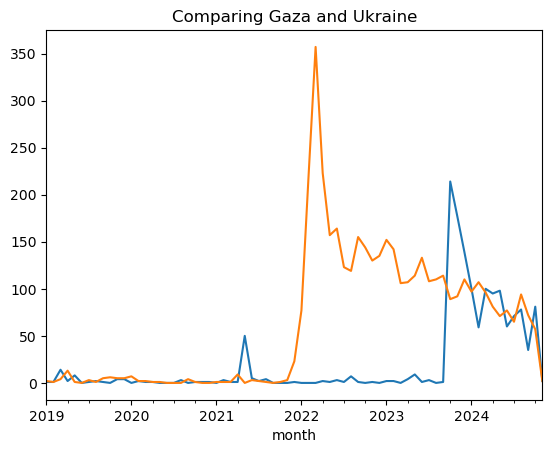

In [24]:
compare_two_words('Gaza', 'Ukraine')

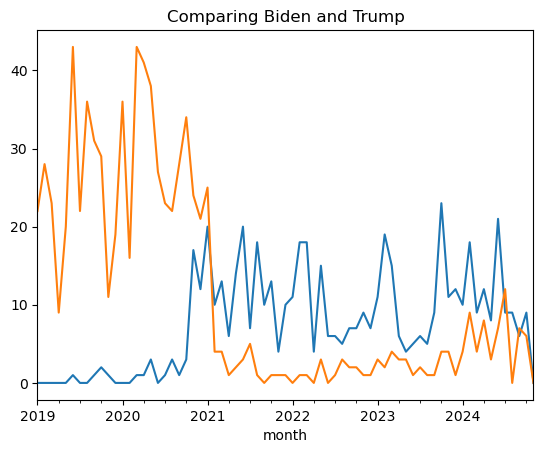

In [26]:
compare_two_words('Biden', 'Trump')

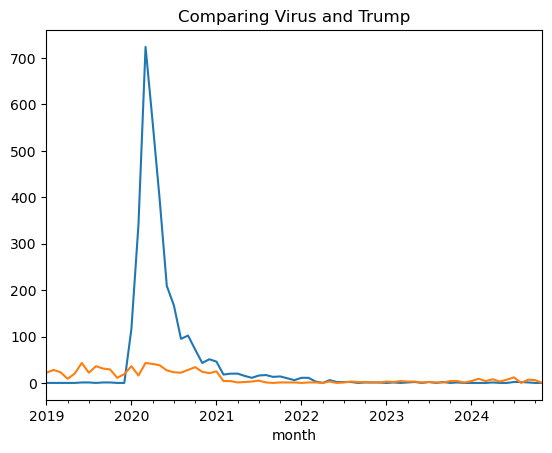

In [27]:
compare_two_words('Virus', 'Trump')

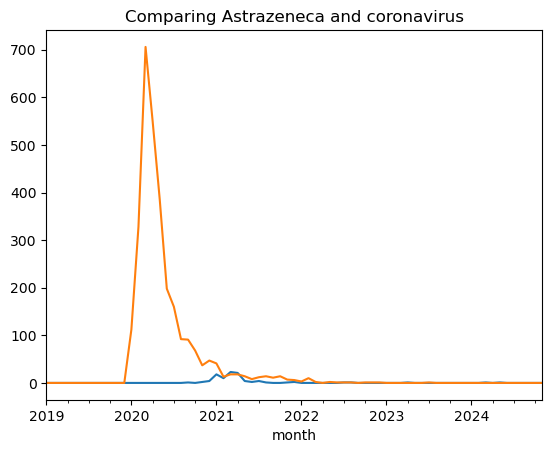

In [34]:
compare_two_words('Astrazeneca', 'coronavirus')

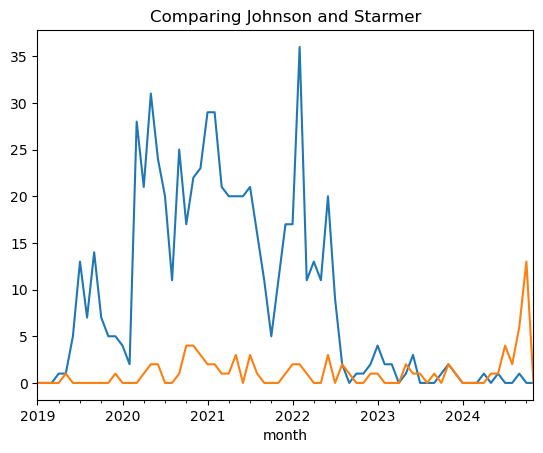

In [36]:
compare_two_words('Johnson', 'Starmer')

In [41]:
def compare_occurence(*words):
    for word in words:
        df[word] = df['headline'].str.contains(word, case=False)
    df['month'] = df['date'].dt.to_period('M')
    for word in words:
        df.groupby('month')[word].sum().plot()
    plt.title(f"Comparing {', '.join(words)}")
    # add legend
    plt.legend(words)
    plt.show()


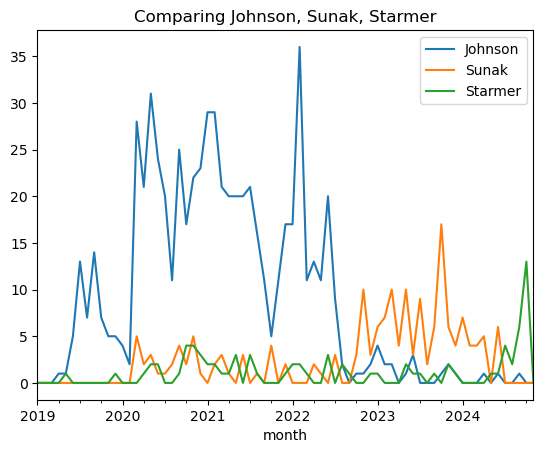

In [42]:
compare_occurence('Johnson', 'Sunak', 'Starmer')

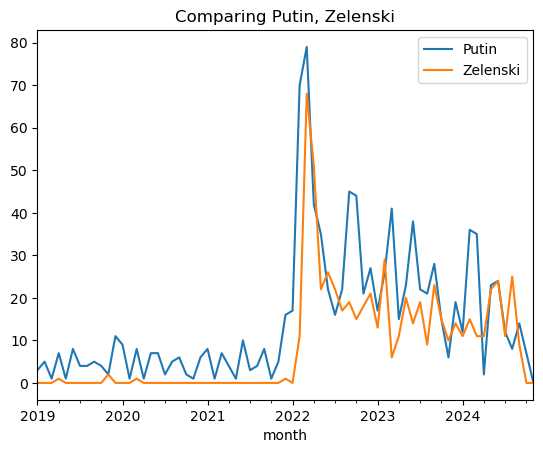

In [45]:
compare_occurence('Putin', 'Zelenski')

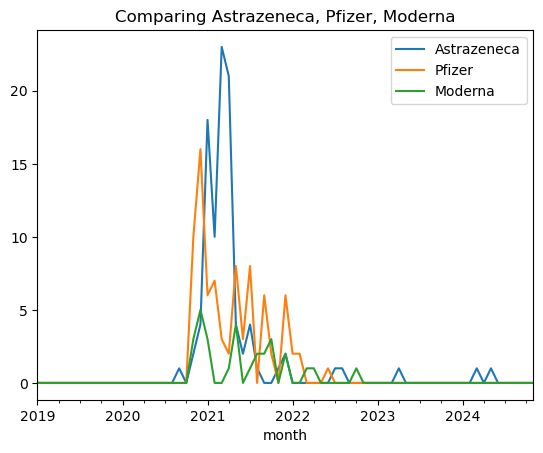

In [46]:
compare_occurence('Astrazeneca', 'Pfizer', 'Moderna')

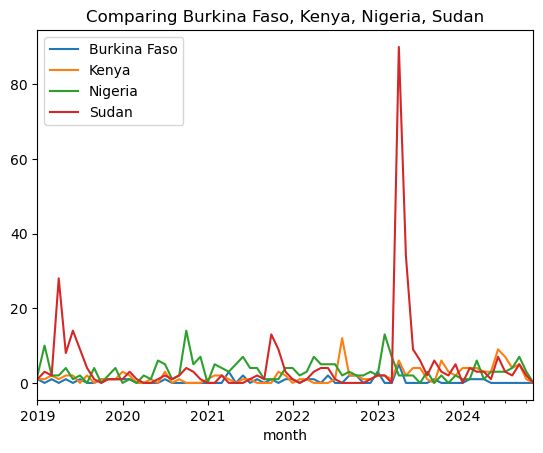

In [50]:
compare_occurence('Burkina Faso', 'Kenya', 'Nigeria', 'Sudan')